# 06 · Голова з attention-пулінгом на ембедінгах усіх фото

У 03 ми агрегували фото тварини фіксовано: *перше* фото та *середнє*. Але фото
різні за корисністю (перше — обкладинка; далі можуть бути дублікати, документи, розмиті кадри).
Тут тварина — це **«мішок» фото** (multiple-instance learning), і мережа сама вчиться,
на які фото дивитися:

- кожне фото = заморожені ембедінги **CLIP ViT-L/14 ⊕ SigLIP2** (768 + 1152 = 1920) + позиційний
  ембедінг (номер фото);
- **gated attention pooling** (Ilse et al., 2018, *Attention-based Deep Multiple Instance Learning*);
- аугментація: під час навчання випадково «ховаємо» 20% фото;
- фіксована кількість епох без early stopping — валідаційний фолд не впливає на модель.

Навчання — секунди на фолд (ембедінги вже закешовані в 03).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.utils import seed_everything, qwk, OptimizedRounder
from src.models import run_lgb_cv

seed_everything(SEED)
pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")

In [2]:
import torch
from dataclasses import replace
from src.image_head import HeadConfig, build_bags, run_head_cv

img_index = pd.read_parquet(PROCESSED_DIR / "image_index.parquet")
train = pd.read_parquet(PROCESSED_DIR / "train_meta.parquet")
test = pd.read_parquet(PROCESSED_DIR / "test_meta.parquet")
y, folds, n_tr = train[TARGET_COL].values.astype(float), train["fold"].values, len(train)
device = "cuda" if torch.cuda.is_available() else "cpu"

img_embs = [np.load(PROCESSED_DIR / "clip_img_emb.npy"), np.load(PROCESSED_DIR / "siglip_img_emb.npy")]
bags_tr, mask_tr = build_bags(img_index, img_embs, train[ID_COL], max_photos=12)
bags_te, mask_te = build_bags(img_index, img_embs, test[ID_COL], max_photos=12)

def load_text(split):
    return torch.from_numpy(np.hstack([np.load(PROCESSED_DIR / f"clip_text_{split}.npy"),
                                       np.load(PROCESSED_DIR / f"siglip_text_{split}.npy")]).astype(np.float16))
text_tr, text_te = load_text("train"), load_text("test")
print("bags:", tuple(bags_tr.shape), " photos per pet capped at 12 (covers 95% of pets fully)")

bags: (6431, 12, 1920)  photos per pet capped at 12 (covers 95% of pets fully)


## 1. Вибір конфігурації

Голова швидко перенавчається (6.4k тварин, 1920-вимірні входи), тому головний
гіперпараметр — кількість епох. Різниця між сідами ≈ ±0.005 QWK — менші відмінності є шумом.

In [3]:
base = HeadConfig(epochs=7)
variants = {
    "5 епох": replace(base, epochs=5),
    "7 епох": base,
    "10 епох": replace(base, epochs=10),
    "20 епох": replace(base, epochs=20),
    "7 епох, без photo-dropout": replace(base, photo_dropout=0.0),
    "7 епох, + токен тексту": replace(base, use_text=True),
}
rows = []
for name, cfg in variants.items():
    res = run_head_cv(bags_tr, mask_tr, bags_te, mask_te, y, folds, cfg, text_tr, text_te, device, verbose=False)
    rows.append({"конфігурація": name, "OOF QWK": res["qwk"], "RMSE": np.sqrt(np.mean((res["oof"] - y) ** 2))})
pd.DataFrame(rows).round(4)

,конфігурація,OOF QWK,RMSE
0,5 епох,0.6090,0.8840
1,7 епох,0.6098,0.8862
2,10 епох,0.6016,0.8988
3,20 епох,0.5841,0.9418
4,"7 епох, без photo-dropout",0.6048,0.8951
5,"7 епох, + токен тексту",0.6095,0.8906


## 2. Фінальна голова: 7 епох × 5 сідів

Текстовий токен не допомагає (текст краще працює окремими моделями у стекінгу),
тому голова — тільки по фото.

In [4]:
oof, pred_te = np.zeros(n_tr), np.zeros(len(test))
seeds = [SEED + s for s in range(5)]
for s in seeds:
    res = run_head_cv(bags_tr, mask_tr, bags_te, mask_te, y, folds, replace(base, seed=s), device=device, verbose=False)
    print(f"seed {s}: OOF QWK {res['qwk']:.4f}")
    oof += res["oof"] / len(seeds); pred_te += res["test"] / len(seeds)

print(f"\n{len(seeds)}-seed OOF QWK: {qwk(y, OptimizedRounder().fit(oof, y).predict(oof)):.4f}")
np.save(PROCESSED_DIR / "oof_head_img.npy", oof); np.save(PROCESSED_DIR / "test_head_img.npy", pred_te)

seed 42: OOF QWK 0.6098


seed 43: OOF QWK 0.6086


seed 44: OOF QWK 0.6116


seed 45: OOF QWK 0.6146


seed 46: OOF QWK 0.6108

5-seed OOF QWK: 0.6112


## 3. На які фото дивиться модель?

Навчаємо одну голову на всьому train і дивимося на ваги attention.

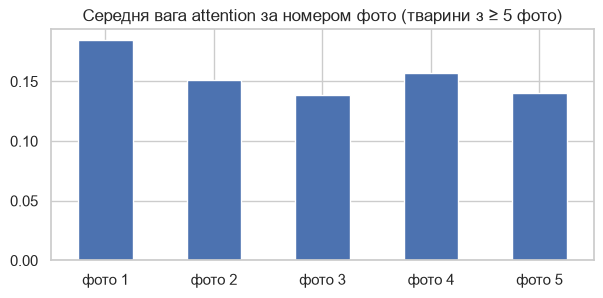

In [5]:
from PIL import Image
from src.image_head import train_head

seed_everything(SEED)
dev_bags, dev_mask = bags_tr.to(device), mask_tr.to(device)
model = train_head(dev_bags, dev_mask, torch.tensor(y, dtype=torch.float32, device=device), base).eval()
with torch.no_grad():
    _, att = model(dev_bags, dev_mask, return_attention=True)
att = att.cpu().numpy()

# Mean attention by photo position, for pets with at least 5 photos
many = mask_tr.sum(1).numpy() >= 5
pd.Series(att[many, :5].mean(0), index=[f"фото {i + 1}" for i in range(5)]).plot.bar(
    title="Середня вага attention за номером фото (тварини з ≥ 5 фото)", rot=0, figsize=(7, 3));

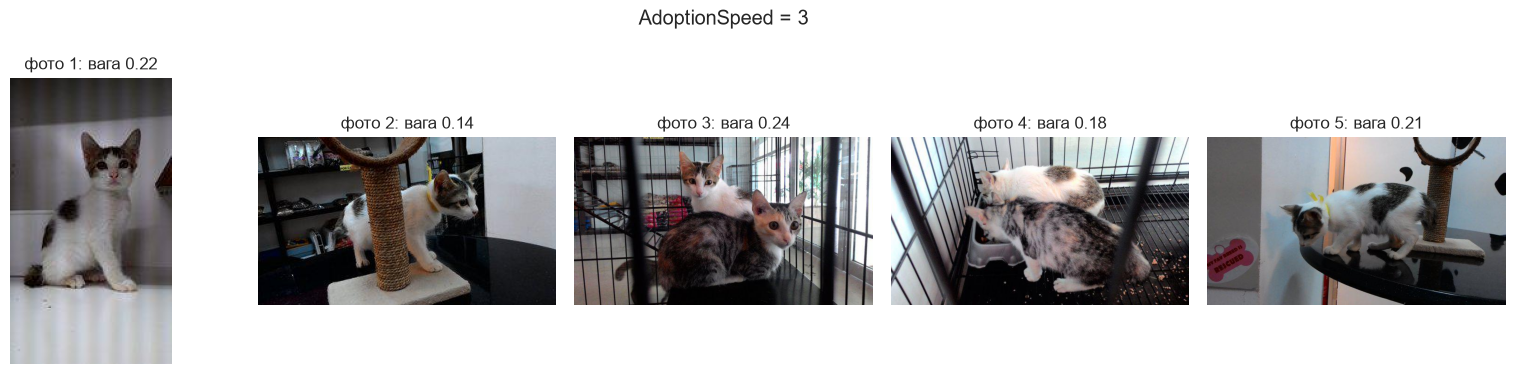

In [6]:
# One pet: photos with their attention weights
rng = np.random.default_rng(SEED)
row = rng.choice(np.where(mask_tr.sum(1).numpy() == 5)[0])
paths = img_index.loc[img_index[ID_COL] == train[ID_COL].iloc[row], "path"].tolist()[:5]
fig, axes = plt.subplots(1, 5, figsize=(16, 3.8))
for i, (ax, p) in enumerate(zip(axes, paths)):
    ax.imshow(Image.open(p)); ax.axis("off"); ax.set_title(f"фото {i + 1}: вага {att[row, i]:.2f}")
fig.suptitle(f"AdoptionSpeed = {int(y[row])}"); plt.tight_layout();

## 4. Чи додає голова щось до стекінгу?

Той самий LightGBM, що й у кінці 03: ознаки тексту, CLIP, SigLIP2 та OOF усіх Ridge-моделей.

In [7]:
def load_pred(name):
    return np.r_[np.load(PROCESSED_DIR / f"oof_{name}.npy"), np.load(PROCESSED_DIR / f"test_{name}.npy")]

def load_feats(name):
    return pd.concat([pd.read_parquet(PROCESSED_DIR / f"{name}_{s}.parquet") for s in ("train", "test")],
                     ignore_index=True).drop(columns=ID_COL)

n_photos = pd.concat([train[["n_photos"]], test[["n_photos"]]], ignore_index=True)
ridge = pd.DataFrame({k: load_pred(k) for k in
                      ["ridge_clip_img", "ridge_tfidf", "ridge_clip_text", "ridge_siglip_img", "ridge_siglip_text"]})
X = pd.concat([n_photos, load_feats("text_feats"), load_feats("img_feats"), load_feats("img_feats_siglip"), ridge], axis=1)

rows = []
for name, X_ in [("стек без голови", X), ("стек + голова", X.assign(head_img=load_pred("head_img")))]:
    rows.append({"ознаки": name, "OOF QWK": run_lgb_cv(X_[:n_tr], X_[n_tr:], y, folds, verbose=False)["qwk"]})
display(pd.DataFrame(rows).round(4))
print("corr(head, ridge_siglip_img) =", np.corrcoef(oof, ridge["ridge_siglip_img"][:n_tr])[0, 1].round(3))

,ознаки,OOF QWK
0,стек без голови,0.617
1,стек + голова,0.621


corr(head, ridge_siglip_img) = 0.944


## Висновки

_(заповнимо на етапі фіналізації)_